# Image Classification using Fashion-MNIST image data (PyTorch)

In [13]:
# PyTorch
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as nnFunc
import torch.amp as amp
# General
import numpy as np
import matplotlib.pyplot as plt
# Optimizer
import torch.optim as optim
# pretty print
from pprint import pprint

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 13.0


## Load image data

Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.

https://github.com/zalandoresearch/fashion-mnist

## 1. Transform setting
The original images are in PIL (0 to 255 for each pixel). First we convert it to a tensor format (0 to 1). Then to make the data to be zero centering, we make the range to be between -1 to 1. If we use the following equation for each data, we can make it zero centered:
\begin{equation}
  output = \frac{input - mean}{std}
\end{equation}
This is being done by setting the `mean` and `standard deviation` to be 0.5.

In [14]:
transform = transforms.Compose( [ transforms.RandomHorizontalFlip(),
                                 transforms.RandomCrop(28, padding=4),
                                 transforms.ToTensor(),
                                 transforms.Normalize((0.5,),
                                                      (0.5,)) 
                                ])


## 2. Making the training set
Now we load the actual dataset and make the training dataset.
1. Load MNIST dataset (Download and prepare dataset)
    1. Put it in `./data_FashionMNIST` directory.
    2. Download it
    3. Do the specified transformation on the dataset
2. Create the data loader (pipelining settings)
    1. Brake it to batches with size of 32
    2. Shuffle the deck in every epoch
    3. Use 4 number of workers to make the training faster

In [15]:
batchSize = 512
numberOfWorkers = 0

trainSet = torchvision.datasets.FashionMNIST(root='./data_FashionMNIST',
                                             train=True,
                                             download=True,
                                             transform=transform)
trainLoader = torch.utils.data.DataLoader(trainSet,
                                          batch_size=batchSize,
                                          shuffle=True,
                                          num_workers=numberOfWorkers,
                                          pin_memory=True,
                                          persistent_workers=False)

## 3. Making the test set
Now making the test set. The procedure is the same as making the training set with some minor modifications.

In [16]:
testSet = torchvision.datasets.FashionMNIST(root='./data_FashionMNIST',
                                       train=False, # Diff
                                       download=True,
                                       transform=transform)
testLoader = torch.utils.data.DataLoader(testSet,
                                         batch_size=batchSize,
                                         shuffle=False, # Diff
                                         num_workers=numberOfWorkers,
                                         pin_memory=True,
                                         persistent_workers=False)

viz_batchSize = 4
vizLoader = torch.utils.data.DataLoader(testSet,
                                        batch_size=viz_batchSize,
                                        shuffle=True)

# 4. The classes

In [17]:
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## DEUBG1
Showing some of the images from the dataset.

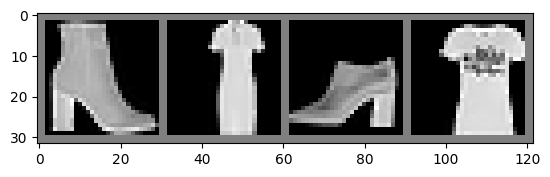

'Ankle boot Dress Ankle boot T-shirt/top'


In [18]:
# functions to show an image
def imshow(img):
  img = img / 2 + 0.5 # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()
# get some random training images
dataiter = iter(vizLoader)
images, labels = next(dataiter)
# show images
imshow(torchvision.utils.make_grid(images))
# print labels
pprint(' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

## 5. Defining the CNN model

In [19]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1    = nn.Conv2d(1, 6, 5, padding='same')
    self.pool     = nn.MaxPool2d(2, 2)
    self.conv2    = nn.Conv2d(6, 16, 5)
    self.fc1      = nn.Linear(16 * 5 * 5, 128)
    self.fc2      = nn.Linear(128, 64)
    self.dropout  = nn.Dropout(0.2)
    self.fc3      = nn.Linear(64, 10)
  
  def forward(self, x):
    x = self.pool(nnFunc.relu(self.conv1(x)))
    x = self.pool(nnFunc.relu(self.conv2(x)))
    x = x.view(-1, 16 * 5 * 5)
    x = nnFunc.relu(self.fc1(x))
    x = nnFunc.relu(self.fc2(x))
    x = self.dropout(x)
    x = self.fc3(x)
    return x

## 6. Instansiating the CNN model

In [20]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
net = Net()
net.apply(init_weights)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

## 7. Move the model to GPU

In [21]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [22]:
net.to(device)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

## 7. Degine loss function and optimizer

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=10)

## 8. Traing the network

In [24]:
scaler = amp.GradScaler('cuda')

epochs = 30
printFrequency = len(trainLoader) // 4

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # --- TRAINING PHASE ---
    for i, data in enumerate(trainLoader, 0):
        inputs, labels = data[0].to(device, non_blocking=True), data[1].to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with amp.autocast('cuda'):
            outputs = net(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()
        
        if i % printFrequency == (printFrequency - 1):
            accuracy = 100 * correct / total
            print(f'Epoch {epoch + 1} | Batch {i + 1}/{len(trainLoader)} | loss: {running_loss / printFrequency:.3f} | acc: {accuracy:.2f}%')
            running_loss, correct, total = 0.0, 0, 0

    # --- VALIDATION PHASE ---
    net.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in testLoader:
            images, labels = data[0].to(device), data[1].to(device)
            with amp.autocast('cuda'):
                outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    print(f'>> Epoch {epoch + 1} SUMMARY: Val Acc: {val_acc:.2f}% | Current LR: {current_lr}')
    
    # --- AUTOMATIC LR DROP ---
    scheduler.step(val_acc)

print('Finished Training')

Epoch 1 | Batch 29/118 | loss: 2.705 | acc: 24.39%
Epoch 1 | Batch 58/118 | loss: 1.391 | acc: 50.09%
Epoch 1 | Batch 87/118 | loss: 1.111 | acc: 60.70%
Epoch 1 | Batch 116/118 | loss: 0.965 | acc: 65.45%
>> Epoch 1 SUMMARY: Val Acc: 71.27% | Current LR: 0.001
Epoch 2 | Batch 29/118 | loss: 0.904 | acc: 67.08%
Epoch 2 | Batch 58/118 | loss: 0.845 | acc: 69.69%
Epoch 2 | Batch 87/118 | loss: 0.807 | acc: 70.50%
Epoch 2 | Batch 116/118 | loss: 0.782 | acc: 71.43%
>> Epoch 2 SUMMARY: Val Acc: 75.02% | Current LR: 0.001
Epoch 3 | Batch 29/118 | loss: 0.746 | acc: 72.53%
Epoch 3 | Batch 58/118 | loss: 0.725 | acc: 73.25%
Epoch 3 | Batch 87/118 | loss: 0.712 | acc: 73.57%
Epoch 3 | Batch 116/118 | loss: 0.704 | acc: 74.04%
>> Epoch 3 SUMMARY: Val Acc: 76.59% | Current LR: 0.001
Epoch 4 | Batch 29/118 | loss: 0.690 | acc: 74.22%
Epoch 4 | Batch 58/118 | loss: 0.670 | acc: 75.22%
Epoch 4 | Batch 87/118 | loss: 0.656 | acc: 75.73%
Epoch 4 | Batch 116/118 | loss: 0.651 | acc: 75.90%
>> Epoch 4 S

## 9. Test the network on the test data

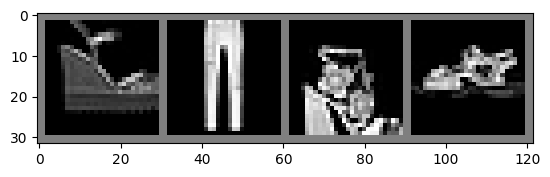

GroundTruth:  Sandal Trouser Ankle boot Sandal


In [25]:
dataIter = iter(vizLoader)
images, labels = next(dataIter)
# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

In [26]:
# Move the data to GPU
images, labels = images.to(device), labels.to(device)

# Now you can run it
outputs = net(images)
_, predicted = torch.max(outputs, 1)

# IMPORTANT: To print, move back to CPU
# Printing needs the labels to be on the CPU so Python can read them
print('Predicted: ', ' '.join(f'{classes[predicted[j].item()]:5s}' for j in range(len(predicted))))

Predicted:  Sandal Trouser Sandal Sandal


## 10. Test the network on the whole dataset

In [27]:
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        
        outputs = net(images)
        
        # 1. Calculate the loss for this batch
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        # 2. Calculate accuracy as before
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate the average loss over all batches
avg_test_loss = test_loss / len(testLoader)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Loss: 0.3830
Test Accuracy: 85.93%


## 11. Check performance within each class

In [28]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: T-shirt/top is 87.1 %
Accuracy for class: Trouser is 96.7 %
Accuracy for class: Pullover is 81.4 %
Accuracy for class: Dress is 88.3 %
Accuracy for class: Coat  is 73.2 %
Accuracy for class: Sandal is 90.9 %
Accuracy for class: Shirt is 51.5 %
Accuracy for class: Sneaker is 93.8 %
Accuracy for class: Bag   is 95.3 %
Accuracy for class: Ankle boot is 95.4 %
